# Result 04 — Taxonomic attention is skewed against described diversity, and is not correcting

Manuscript-complete for the finding: every value the section reports is computed here.

| Section | What it carries |
| --- | --- |
| 1 | Scope and the single denominator |
| 2 | Attention versus described diversity |
| 2b | **The manuscript figure** — the skew and its trajectory |
| 2c | Supplementary — where each group is studied |
| 2d | **Ongoing** — vertebrate evidence versus threatened vertebrates (backs nothing yet) |
| 3 | Interpretation boundaries and the manifest |

Sections 1–2b are manuscript-only. 2c is supplementary, and **2d is exploratory**: it is
kept here because it shares 2c's location-quotient frame, but it supports no sentence in
either the Results or the Supplementary and its tables are listed under a separate manifest
key so they cannot be mistaken for manuscript-backing output.

The driver-conditioned lens (driver x taxon location quotients, resolution by driver,
concentration versus inclusiveness) was **retired on 2026-08-02**: it has no external
benchmark, its effect sizes are an order of magnitude smaller than the skew's, and the one
claim that would have compounded the finding — that under-attended groups are studied through
fewer drivers — is false (invertebrates 4.05 effective drivers, vertebrates 4.39). Snapshot in
`archive/retired-helpers/2026-08-02-f4-driver-lens/`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config, visualization
from data_helpers.prep import taxa_analysis_prep
from data_helpers.analysis.taxa import skew as taxa_skew
from data_helpers.analysis.taxa import skew_plotting as taxa_skew_plotting
from data_helpers.analysis.taxa import geography as taxa_geography

In [2]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
# One analysis key. Everything else read here is shared infrastructure: the two
# data-processing handoffs (taxa_analysis_prep, and the corpus for study countries).
CONFIG = RESULTS_CONFIG["taxonomic_lens"]
PREP_CONFIG = RESULTS_CONFIG["taxa_analysis_prep"]

# Resolved at runtime rather than pinned in config: the manuscript .tex is renumbered
# in Overleaf independently of this repo, so a literal path here goes stale silently.
manuscript_candidates = sorted(
    (PROJECT_ROOT / "checklists" / "overleaf" / "main").glob("main-*.tex"),
    key=lambda path: int(path.stem.rsplit("-", 1)[-1]),
)
MANUSCRIPT_SOURCE = str(manuscript_candidates[-1].relative_to(PROJECT_ROOT))

MAPPING = taxa_analysis_prep.load_taxa_mapping(PROJECT_ROOT / PREP_CONFIG["taxa_group_mapping"])
BROAD_SCHEME = MAPPING["schemes"]["broad"]

BENCHMARK_GROUPS = tuple(CONFIG["benchmark_groups"])
BROAD_COLORS = {group: BROAD_SCHEME["group_colors"][group] for group in BENCHMARK_GROUPS}

PREPARED = taxa_analysis_prep.TaxaPreparedStore(PROJECT_ROOT / PREP_CONFIG["output_directory"])
RESULTS = taxa_skew.TaxaSkewResultStore(
    PROJECT_ROOT / CONFIG["output_directory"],
    table_subdirectory=CONFIG["table_subdirectory"],
    figure_subdirectory=CONFIG["figure_subdirectory"],
)
ARTIFACT_PREFIX = CONFIG["artifact_prefix"]


# Every exported file carries this result's prefix.
def artifact(name: str) -> str:
    return f"{ARTIFACT_PREFIX}_{name}"


print(f"Benchmark groups: {', '.join(BENCHMARK_GROUPS)}")
print(f"Stack order (bottom to top): {', '.join(CONFIG['benchmark_group_stack_order'])}")
print(f"Outputs: {CONFIG['output_directory']}")

Benchmark groups: Vertebrates, Invertebrates, Plants, Fungi, Other
Stack order (bottom to top): Invertebrates, Fungi, Other, Plants, Vertebrates
Outputs: notebooks/results/outputs/04_taxonomic_lens


## 1. One load, two denominators

The handoff is loaded once and two scopes are cut from it. Both are negative-direction
evidence from complete years 2000–2025.

- **Anchor scope** — publications with at least one benchmarkable *broad* group.
  Answers "how skewed is the field against described diversity?"
- **Driver scope** — publications with at least one benchmarkable *analysis* group
  **and** at least one configured IPBES driver. Answers "does the skew depend on the
  driver?"

The driver scope is a subset. Any corpus-wide share quoted alongside driver-conditioned
shares must come from the driver scope, or the sentence compares two populations.

In [3]:
bundle = PREPARED.load(mapping=MAPPING)
print(f"Handoff: {len(bundle.articles):,} rows / {bundle.articles['UT'].nunique():,} unique UTs.")
print(f"Grouping rules SHA-256: {bundle.manifest['grouping_rules_sha256'][:16]}…")

anchor = taxa_skew.prepare_taxa_skew_from_prepared(
    bundle.articles,
    benchmark_groups=BENCHMARK_GROUPS,
    unresolved_group=CONFIG["unresolved_group"],
    match_status_audit=bundle.audit_frame("match_status"),
    group_reason_audit=bundle.audit_frame("broad_group_reason"),
    special_value_audit=bundle.audit_frame("special_value"),
    auxiliary_label_audit=bundle.audit_frame("auxiliary_labels"),
    direction=CONFIG["direction"],
    start_year=CONFIG["primary_start_year"],
    end_year=CONFIG["primary_end_year"],
)

# The universe is every in-scope publication; the anchor is those that resolve to a
# benchmarkable broad group. The gap between them is the resolution caveat, reported in 2b.
UNIVERSE = bundle.articles[
    bundle.articles["s2_dir"].eq(CONFIG["direction"])
    & bundle.articles["publication_year"].between(
        CONFIG["primary_start_year"], CONFIG["primary_end_year"]
    )
]
N_UNIVERSE = int(UNIVERSE["UT"].nunique())
N_ANCHOR = int(anchor.included["UT"].nunique())

Handoff: 605,199 rows / 605,199 unique UTs.
Grouping rules SHA-256: c211129eb583ecf5…


In [4]:
denominators = pd.DataFrame(
    [
        {
            "scope": "Universe (negative, 2000–2025)",
            "requirement": "in scope",
            "n_publications": N_UNIVERSE,
            "share_of_universe_pct": 100.0,
        },
        {
            "scope": "Anchor (the finding)",
            "requirement": "≥1 benchmarkable broad group",
            "n_publications": N_ANCHOR,
            "share_of_universe_pct": N_ANCHOR / N_UNIVERSE * 100,
        },
    ]
)
RESULTS.save_table(denominators, artifact("denominators"))
display(
    denominators.style.format(
        {"n_publications": "{:,}", "share_of_universe_pct": "{:.2f}%"}
    ).hide(axis="index")
)
print(
    f"{N_UNIVERSE - N_ANCHOR:,} in-scope publications name no benchmarkable group and are "
    "excluded from every number below."
)

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_denominators.csv


scope,requirement,n_publications,share_of_universe_pct
"Universe (negative, 2000–2025)",in scope,"245,168",100.00%
Anchor (the finding),≥1 benchmarkable broad group,"171,791",70.07%


73,377 in-scope publications name no benchmarkable group and are excluded from every number below.


## 2. Attention versus described diversity

The comparison the finding rests on: each broad group's share of publication attention against
its share of described species. Attention is article-balanced — a publication naming two groups
contributes half a publication to each, never one to both.

In [5]:
benchmark = bundle.benchmark
anchor_analysis = taxa_skew.analyze_taxonomic_skew(
    anchor,
    benchmark,
    benchmark_groups=BENCHMARK_GROUPS,
    n_bootstrap=CONFIG["bootstrap_replicates"],
    seed=CONFIG["random_seed"],
)
RESULTS.save_table(anchor_analysis.comparison, artifact("attention_vs_described_diversity"))

display(
    anchor_analysis.comparison[
        [
            "broad_group",
            "n_unique_publications",
            "fractional_attention_share_pct",
            "attention_ci_low_pct",
            "attention_ci_high_pct",
            "described_species_count",
            "described_species_share_pct",
            "attention_minus_described_pp",
            "representation_ratio",
            "representation",
        ]
    ]
    .style.format(
        {
            "n_unique_publications": "{:,}",
            "fractional_attention_share_pct": "{:.2f}%",
            "attention_ci_low_pct": "{:.2f}%",
            "attention_ci_high_pct": "{:.2f}%",
            "described_species_count": "{:,}",
            "described_species_share_pct": "{:.2f}%",
            "attention_minus_described_pp": "{:+.2f} pp",
            "representation_ratio": "{:.2f}×",
        }
    )
    .hide(axis="index")
)

ANCHOR = anchor_analysis.comparison.set_index("broad_group")
for group in ("Vertebrates", "Invertebrates"):
    row = ANCHOR.loc[group]
    print(
        f"{group}: {row['fractional_attention_share_pct']:.1f}% of attention versus "
        f"{row['described_species_share_pct']:.1f}% of described species "
        f"({row['representation_ratio']:.2f}×, {row['attention_minus_described_pp']:+.1f} pp)."
    )

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_vs_described_diversity.csv


broad_group,n_unique_publications,fractional_attention_share_pct,attention_ci_low_pct,attention_ci_high_pct,described_species_count,described_species_share_pct,attention_minus_described_pp,representation_ratio,representation
Vertebrates,"64,161",34.83%,34.59%,35.05%,"119,596",4.62%,+30.21 pp,7.54×,Over-attended
Invertebrates,"39,952",19.71%,19.53%,19.90%,"1,683,461",64.98%,-45.27 pp,0.30×,Under-attended
Plants,"65,412",33.99%,33.77%,34.21%,"443,824",17.13%,+16.86 pp,1.98×,Over-attended
Fungi,"7,518",2.94%,2.87%,3.01%,"171,668",6.63%,-3.69 pp,0.44×,Under-attended
Other,"18,673",8.54%,8.41%,8.65%,"172,283",6.65%,+1.89 pp,1.28×,Over-attended


Vertebrates: 34.8% of attention versus 4.6% of described species (7.54×, +30.2 pp).
Invertebrates: 19.7% of attention versus 65.0% of described species (0.30×, -45.3 pp).


### 2a. The geographic comparison

Everything the geographic claim needs, built once here so the taxonomic and geographic
halves cannot drift apart across sections. Section 2b plots it; section 2c tests it against
the obvious objection.

The benchmark changes but the question does not. Section 2 asks whether attention tracks
**described diversity**; this asks whether, within one group, evidence tracks **documented
threat**. The two benchmarks are unrelated — GBIF accepted species and IUCN threatened
birds + mammals — which is what makes the pair worth reporting together.

Counting matches `summarise_gap_by_region` throughout: unique documents per country, summed
within region, so a yearly share and the pooled share are the same statistic at different
resolutions.

**Regions are the unit the claim rests on.** Country cells are exported for the Supplementary
and carry a 95% credible interval, but many rest on counts too small to support a ratio, and
`signal_is_conclusive` is what separates the two. The countries the text names are chosen on
a large **absolute** deficit in a country that is not short of a research base — never on a
ratio, which would put Qatar (14 threatened species) above Indonesia (373).

In [6]:
import numpy as np

from data_helpers.analysis.geo.geography import load_crosswalk
from data_helpers.analysis.taxa import threat_gap as taxa_threat_gap
from data_helpers.analysis.taxa import threat_gap_plotting as taxa_gap_plotting

GAP_GROUP = CONFIG["threat_gap_group"]
GAP_SLUG = taxa_geography.group_slug(GAP_GROUP)
CROSSWALK = load_crosswalk()

publication_countries = taxa_geography.load_publication_countries(
    PROJECT_ROOT / CONFIG["geography_source"]
)
taxa_lq, taxa_geo_audit, taxa_geo_coverage = taxa_geography.taxa_country_specialization(
    anchor.included,
    publication_countries,
    benchmark_groups=BENCHMARK_GROUPS,
    min_support=CONFIG["geography_min_support"],
    eb_kappa=CONFIG["geography_eb_kappa"],
)

# Coverage of the geographic comparison -- the share of the anchor carrying a mapped
# study country. Reported as an interpretation boundary, so it is exported, not only printed.
RESULTS.save_table(taxa_geo_coverage, artifact("taxa_geography_coverage"))
# Reported later as an interpretation boundary (Section 3), computed here
# alongside taxa_geo_coverage so it cannot drift from the frame it summarises.
GEO_COVERAGE_PCT = float(taxa_geo_coverage.loc[1, "share_of_scope_pct"])

# (1) Evidence side. Every country the LQ was computed for, cutoff flagged not applied.
gap_evidence = taxa_threat_gap.evidence_by_country(taxa_lq, CROSSWALK, group=GAP_GROUP)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_evidence, "evidence-by-country"),
    artifact(f"{GAP_SLUG}_evidence_by_country"),
)
print(
    f"(1) Evidence: {len(gap_evidence):,} countries, "
    f"{gap_evidence['n_group_publications'].sum():,} {GAP_GROUP.lower()} publications; "
    f"{int(gap_evidence['meets_min_support'].sum())} clear the "
    f"{CONFIG['geography_min_support']}-publication line, "
    f"{int((~gap_evidence['meets_min_support']).sum())} fall below it and are kept anyway."
)
display(
    gap_evidence.head(15)
    .style.format(
        {
            "n_group_publications": "{:,}",
            "n_country_publications": "{:,}",
            "share_of_group_evidence_pct": "{:.2f}%",
            "within_country_share_pct": "{:.1f}%",
            "corpus_share_pct": "{:.1f}%",
            "lq": "{:.2f}×",
            "log2_lq": "{:+.2f}",
            "lq_eb": "{:.2f}×",
            "log2_lq_eb": "{:+.2f}",
        }
    )
    .hide(axis="index")
)

# (2) Threat side, independent of the corpus entirely.
gap_threat = taxa_threat_gap.threatened_species_by_country(
    PROJECT_ROOT / CONFIG["threat_gap_source"]
)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_threat, "threatened-species-by-country"),
    artifact("threatened_species_by_country"),
)
# These are constant down every row, so they are facts about the table rather than
# columns in it -- stated here and in the manifest instead of repeated 215 times.
print(
    f"\n(2) Threat: {len(gap_threat):,} countries, WDI year "
    f"{int(gap_threat['wdi_year'].max())}; "
    f"{int((~gap_threat['threat_counts_complete']).sum())} with an incomplete class set. "
    f"Fish are {gap_threat['threatened_fish'].sum() / gap_threat['threatened_vertebrates'].sum() * 100:.0f}% "
    "of the birds+mammals+fish total, which is why the land subset is held apart."
)
display(
    gap_threat.head(15)
    .style.format(
        {
            column: "{:,.0f}"
            for column in (
                *taxa_threat_gap.THREAT_INDICATORS.values(),
                "threatened_vertebrates",
                "threatened_vertebrates_land",
                "threatened_total",
            )
        }
        | {"vertebrate_share_of_threatened_pct": "{:.1f}%", "wdi_year": "{:.0f}"}
    )
    .hide(axis="index")
)

# (2b) Research-capacity covariates, same snapshot and same ISO3 spine. Carried
# beside the score, never folded into it: a deficit that vanishes once national
# scientific output is accounted for is a capacity story; one that survives is an
# allocation story. Coverage is thinner than the threat side, and stays null where absent.
gap_capacity = taxa_threat_gap.research_capacity_by_country(
    PROJECT_ROOT / CONFIG["threat_gap_source"]
)
CAPACITY_COLUMNS = tuple(taxa_threat_gap.CAPACITY_INDICATORS.values())
print("\n(2b) Capacity covariates -- coverage across the WDI snapshot:")
for column in CAPACITY_COLUMNS:
    print(f"    {column:<26}: {int(gap_capacity[column].notna().sum()):>3} countries")

# (3) The match. Inner: the exported table carries only countries with BOTH sides,
# which are the rows a ratio is defined on. This changes no value -- shares and ratios
# were always computed over matched countries -- it only decides which rows are kept.
# What is excluded is reported below rather than dropped silently.
gap_matched = taxa_threat_gap.match_evidence_and_threat(
    gap_evidence, gap_threat, covariates=gap_capacity
)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_matched, "evidence-vs-threatened"),
    artifact(f"{GAP_SLUG}_evidence_vs_threatened"),
)
BOTH = gap_matched
EXCLUDED = gap_matched.attrs
print(f"\n(3) Match -- exported table is countries on BOTH sides only:")
print(f"    matched         : {EXCLUDED['n_matched_countries']:>4} countries (exported)")
print(
    f"    evidence only   : {EXCLUDED['n_evidence_only_countries']:>4} countries, "
    f"{EXCLUDED['evidence_only_publications']:,.0f} publications (excluded)"
)
print(
    f"    threat only     : {EXCLUDED['n_threat_only_countries']:>4} countries, "
    f"{EXCLUDED['threat_only_threatened_vertebrates_land']:,.0f} threatened land "
    "vertebrates (excluded)"
)
print(
    f"    retained: {BOTH['n_group_publications'].sum():,.0f} of "
    f"{gap_evidence['n_group_publications'].sum():,.0f} {GAP_GROUP.lower()} publications "
    f"({BOTH['n_group_publications'].sum() / gap_evidence['n_group_publications'].sum() * 100:.1f}%) "
    f"and {BOTH['threatened_vertebrates_land'].sum():,.0f} of "
    f"{gap_threat['threatened_vertebrates_land'].sum():,.0f} threatened land vertebrates "
    f"({BOTH['threatened_vertebrates_land'].sum() / gap_threat['threatened_vertebrates_land'].sum() * 100:.1f}%)."
)
# Named, because the largest exclusion is a policy artefact rather than a data gap:
# the World Bank has no economy for Taiwan, so it cannot appear on the threat side.
print(f"    evidence-only countries: {', '.join(EXCLUDED['evidence_only_countries'])}")
print(f"    threat-only countries  : {', '.join(EXCLUDED['threat_only_countries'])}")

RATIO_COLUMN = "evidence_to_threatened_vertebrates_land_ratio"
GAP_VIEW = [
    "iso3",
    "country",
    "region",
    "n_group_publications",
    "matched_evidence_share_pct",
    "threatened_vertebrates_land",
    "matched_threatened_vertebrates_land_share_pct",
    RATIO_COLUMN,
    "meets_min_support",
]
GAP_FORMAT = {
    "n_group_publications": "{:,}",
    "matched_evidence_share_pct": "{:.2f}%",
    "threatened_vertebrates_land": "{:,.0f}",
    "matched_threatened_vertebrates_land_share_pct": "{:.2f}%",
    RATIO_COLUMN: "{:.2f}×",
}
ranked = BOTH.dropna(subset=[RATIO_COLUMN]).sort_values(RATIO_COLUMN)
print(f"\nMost under-studied relative to threatened land vertebrates ({len(ranked)} countries ranked):")
display(ranked.head(12)[GAP_VIEW].style.format(GAP_FORMAT).hide(axis="index"))
print("Most over-studied:")
display(ranked.tail(12)[::-1][GAP_VIEW].style.format(GAP_FORMAT).hide(axis="index"))


# The geographic row of the manuscript figure. The regional table is the defensible
# unit -- country cells rest on counts too small to carry a ratio -- and the trend
# answers on the geographic axis the question panel B answers on the taxonomic one.
gap_regions = taxa_threat_gap.summarise_gap_by_region(gap_matched)
gap_regional_trend = taxa_threat_gap.regional_evidence_trend(
    anchor.included, publication_countries, gap_regions, CROSSWALK, group=GAP_GROUP
)
gap_regional_summary = taxa_threat_gap.summarise_regional_trend(gap_regional_trend)
RESULTS.save_table(gap_regions, artifact(f"{GAP_SLUG}_evidence_vs_threatened_by_region"))
RESULTS.save_table(
    gap_regional_trend, artifact(f"{GAP_SLUG}_regional_evidence_trend")
)
RESULTS.save_table(
    gap_regional_summary, artifact(f"{GAP_SLUG}_regional_evidence_trend_summary")
)
display(
    gap_regional_summary.style.format(
        {
            "start_share_pct": "{:.2f}%",
            "end_share_pct": "{:.2f}%",
            "change_pp": "{:+.2f} pp",
            "slope_pp_per_decade": "{:+.2f}",
            "threat_share_pct": "{:.2f}%",
            "start_ratio": "{:.2f}×",
            "end_ratio": "{:.2f}×",
        }
    ).hide(axis="index")
)
for row in gap_regional_summary.itertuples():
    print(
        f"{row.region}: {row.start_share_pct:.1f}% -> {row.end_share_pct:.1f}% of "
        f"{GAP_GROUP.lower()} evidence ({row.slope_pp_per_decade:+.2f} pp/decade); "
        f"representation {row.start_ratio:.2f}x -> {row.end_ratio:.2f}x."
    )

# Robustness: Asia-Pacific's rise is the sharpest in the table, and WoS expanded its
# coverage of Chinese journals over the same window, so the region's own largest
# country is a live confound. Two checks: how much of the region's evidence China is
# in each year, and how the regional slope reads with China held out entirely. Both
# reuse `regional_evidence_trend` rather than a bespoke computation, so the sensitivity
# is scored by the same code as the headline, not a parallel implementation of it.
GAP_APAC_REGION = "Asia and the Pacific"
APAC_SPLIT_CROSSWALK = CROSSWALK[CROSSWALK["region"] == GAP_APAC_REGION].copy()
APAC_SPLIT_CROSSWALK["region"] = np.where(
    APAC_SPLIT_CROSSWALK["iso3"] == "CHN", "China", "Asia-Pacific (excl. China)"
)
APAC_SPLIT_BENCHMARK = pd.DataFrame(
    {
        "region": ["China", "Asia-Pacific (excl. China)"],
        "threat_share_pct": [50.0, 50.0],
    }
)
gap_china_share_trend = taxa_threat_gap.regional_evidence_trend(
    anchor.included, publication_countries, APAC_SPLIT_BENCHMARK,
    APAC_SPLIT_CROSSWALK, group=GAP_GROUP,
)
_china_rows = gap_china_share_trend.query("region == 'China'").sort_values(
    "publication_year"
)
CHINA_SHARE_START = float(_china_rows["evidence_share_pct"].iloc[0])
CHINA_SHARE_END = float(_china_rows["evidence_share_pct"].iloc[-1])

gap_regional_trend_no_china = taxa_threat_gap.regional_evidence_trend(
    anchor.included, publication_countries, gap_regions, CROSSWALK,
    group=GAP_GROUP, exclude_iso3=["CHN"],
)
gap_regional_summary_no_china = taxa_threat_gap.summarise_regional_trend(
    gap_regional_trend_no_china
)
RESULTS.save_table(
    gap_regional_summary_no_china,
    artifact(f"{GAP_SLUG}_regional_evidence_trend_summary_excl_china"),
)
APAC_SLOPE_FULL = gap_regional_summary.set_index("region").loc[
    GAP_APAC_REGION, "slope_pp_per_decade"
]
APAC_SLOPE_NO_CHINA = gap_regional_summary_no_china.set_index("region").loc[
    GAP_APAC_REGION, "slope_pp_per_decade"
]
print(
    f"\nChina confound: China was {CHINA_SHARE_START:.1f}% of {GAP_APAC_REGION} "
    f"{GAP_GROUP.lower()} evidence in the first study year and "
    f"{CHINA_SHARE_END:.1f}% in the last."
)


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_taxa_geography_coverage.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_by_country.csv
(1) Evidence: 236 countries, 43,809 vertebrates publications; 104 clear the 100-publication line, 132 fall below it and are kept anyway.


iso3,country,region,subregion,broad_group,n_group_publications,n_country_publications,share_of_group_evidence_pct,within_country_share_pct,corpus_share_pct,lq,log2_lq,lq_eb,log2_lq_eb,meets_min_support
USA,United States of America (the),Americas,North America,Vertebrates,"8,751","19,006",19.98%,46.0%,39.7%,1.16×,+0.22,1.16×,+0.21,True
CAN,Canada,Americas,North America,Vertebrates,"2,802","5,090",6.40%,55.0%,39.7%,1.39×,+0.47,1.39×,+0.47,True
CHN,China,Asia and the Pacific,North-East Asia,Vertebrates,"2,659","9,727",6.07%,27.3%,39.7%,0.69×,-0.54,0.69×,-0.54,True
AUS,Australia,Asia and the Pacific,Oceania,Vertebrates,"2,308","5,040",5.27%,45.8%,39.7%,1.15×,+0.21,1.15×,+0.21,True
BRA,Brazil,Americas,South America,Vertebrates,"2,262","5,662",5.16%,40.0%,39.7%,1.01×,+0.01,1.01×,+0.01,True
ESP,Spain,Europe and Central Asia,Central and Western Europe,Vertebrates,"1,262","3,319",2.88%,38.0%,39.7%,0.96×,-0.06,0.96×,-0.06,True
IND,India,Asia and the Pacific,South Asia,Vertebrates,"1,168","3,663",2.67%,31.9%,39.7%,0.80×,-0.32,0.81×,-0.31,True
MEX,Mexico,Americas,Mesoamerica,Vertebrates,"1,075","2,435",2.45%,44.1%,39.7%,1.11×,+0.15,1.11×,+0.15,True
GBR,United Kingdom of Great Britain and Northern Ireland (the),Europe and Central Asia,Central and Western Europe,Vertebrates,945,"2,052",2.16%,46.1%,39.7%,1.16×,+0.22,1.16×,+0.21,True
ITA,Italy,Europe and Central Asia,Central and Western Europe,Vertebrates,870,"2,688",1.99%,32.4%,39.7%,0.82×,-0.29,0.82×,-0.29,True


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_threatened_species_by_country.csv

(2) Threat: 215 countries, WDI year 2022; 0 with an incomplete class set. Fish are 61% of the birds+mammals+fish total, which is why the land subset is held apart.


iso3,country,region,subregion,wdi_year,threatened_birds,threatened_mammals,threatened_fish,threatened_higher_plants,threatened_vertebrates,threatened_vertebrates_land,threatened_total,vertebrate_share_of_threatened_pct,threat_counts_complete
MDG,Madagascar,Africa,East Africa and adjacent islands,2022,37,133,127,"2,894",297,170,"3,191",9.3%,True
ECU,Ecuador,Americas,South America,2022,86,49,99,"2,029",234,135,"2,263",10.3%,True
BRA,Brazil,Americas,South America,2022,155,97,360,"1,346",612,252,"1,958",31.3%,True
MEX,Mexico,Americas,Mesoamerica,2022,68,97,308,"1,426",473,165,"1,899",24.9%,True
IDN,Indonesia,Asia and the Pacific,South-East Asia,2022,161,212,366,977,739,373,"1,716",43.1%,True
MYS,Malaysia,Asia and the Pacific,South-East Asia,2022,67,80,183,"1,317",330,147,"1,647",20.0%,True
TZA,"Tanzania, the United Republic of",Africa,East Africa and adjacent islands,2022,46,45,219,"1,010",310,91,"1,320",23.5%,True
COL,Colombia,Americas,South America,2022,102,63,183,918,348,165,"1,266",27.5%,True
PHL,Philippines (the),Asia and the Pacific,South-East Asia,2022,91,42,143,903,276,133,"1,179",23.4%,True
CMR,Cameroon,Africa,Central Africa,2022,31,48,148,888,227,79,"1,115",20.4%,True



(2b) Capacity covariates -- coverage across the WDI snapshot:
    gdp_per_capita_usd        : 213 countries
    rd_expenditure_pct_gdp    : 156 countries
    researchers_per_million   : 145 countries
    scientific_articles       : 197 countries
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_vs_threatened.csv

(3) Match -- exported table is countries on BOTH sides only:
    matched         :  213 countries (exported)
    evidence only   :   23 countries, 332 publications (excluded)
    threat only     :    2 countries, 5 threatened land vertebrates (excluded)
    retained: 43,477 of 43,809 vertebrates publications (99.2%) and 8,388 of 8,393 threatened land vertebrates (99.9%).
    evidence-only countries: AIA, BES, BLM, BVT, CCK, COK, CXR, ESH, FLK, GLP, GUF, IOT, MSR, MTQ, MYT, NIU, PCN, REU, SGS, SHN, TKL, TWN, WLF
    threat-only countries  : MAF, SMR

Most under-studied relative to threatened land vertebr

...

iso3,country,region,n_group_publications,matched_evidence_share_pct,threatened_vertebrates_land,matched_threatened_vertebrates_land_share_pct,evidence_to_threatened_vertebrates_land_ratio,meets_min_support
CAN,Canada,Americas,"2,802.0",6.44%,40,0.48%,13.51×,True
USA,United States of America (the),Americas,"8,751.0",20.13%,130,1.55%,12.99×,True
GBR,United Kingdom of Great Britain and Northern Ireland (the),Europe and Central Asia,945.0,2.17%,15,0.18%,12.15×,True
NOR,Norway,Europe and Central Asia,768.0,1.77%,19,0.23%,7.80×,True
ITA,Italy,Europe and Central Asia,870.0,2.00%,28,0.33%,5.99×,True
ESP,Spain,Europe and Central Asia,"1,262.0",2.90%,42,0.50%,5.80×,True
SWE,Sweden,Europe and Central Asia,383.0,0.88%,13,0.15%,5.68×,True
DEU,Germany,Europe and Central Asia,522.0,1.20%,19,0.23%,5.30×,True
FIN,Finland,Europe and Central Asia,320.0,0.74%,14,0.17%,4.41×,True
FRA,France,Europe and Central Asia,699.0,1.61%,32,0.38%,4.21×,True


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_vs_threatened_by_region.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_regional_evidence_trend.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_regional_evidence_trend_summary.csv


region,start_year,end_year,start_share_pct,end_share_pct,change_pp,slope_pp_per_decade,threat_share_pct,start_ratio,end_ratio
Africa,2000,2025,6.90%,9.70%,+2.80 pp,+1.21,27.61%,0.25×,0.35×
Asia and the Pacific,2000,2025,17.24%,35.31%,+18.07 pp,+6.06,36.71%,0.47×,0.96×
Europe and Central Asia,2000,2025,25.48%,20.28%,-5.19 pp,-2.99,13.70%,1.86×,1.48×
Americas,2000,2025,50.38%,34.71%,-15.68 pp,-4.28,21.98%,2.29×,1.58×


Africa: 6.9% -> 9.7% of vertebrates evidence (+1.21 pp/decade); representation 0.25x -> 0.35x.
Asia and the Pacific: 17.2% -> 35.3% of vertebrates evidence (+6.06 pp/decade); representation 0.47x -> 0.96x.
Europe and Central Asia: 25.5% -> 20.3% of vertebrates evidence (-2.99 pp/decade); representation 1.86x -> 1.48x.
Americas: 50.4% -> 34.7% of vertebrates evidence (-4.28 pp/decade); representation 2.29x -> 1.58x.


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_regional_evidence_trend_summary_excl_china.csv

China confound: China was 4.4% of Asia and the Pacific vertebrates evidence in the first study year and 35.5% in the last.


### 2b. Manuscript figure — two mismatches and what happened to each

The F4 figure. **Columns are the two questions, rows are the two axes**: left, does attention
match the benchmark; right, has that changed over 25 years. Top row taxonomic, bottom row
geographic.

- **Panel A** — described-species share and research-attention share as two stacked bars on a
  *shared* 0–100% axis, joined by ribbons. One axes on purpose: the contrast is only readable
  on a common scale.
- **Panel B** — attention share by publication year. **The claim is stability**: output grew
  sevenfold while composition barely moved, and the most under-represented group did not gain.
  Flat lines are the evidence, so the axis runs 0–42% and is never zoomed.
- **Panel C** — the same construction against a *different, unrelated* benchmark: each IPBES
  region's share of threatened birds + mammals against its share of vertebrate evidence. That
  two independent yardsticks (GBIF described species, IUCN threatened species) both fail is
  what makes the pair worth reporting together.
- **Panel D** — regional share of vertebrate evidence by year, and it does **not** repeat panel
  B. The geographic gap has narrowed substantially: Asia and the Pacific 0.47× → 0.96× of its
  threat share, the Americas 2.29× → 1.58×. Africa improved least and remains the deepest gap
  (0.25× → 0.35×).

**That contrast is the finding, not an inconsistency.** The field demonstrably corrected on one
axis while the other stood still, so taxonomic stasis is not an inevitability of how research
grows.

`Other` is plotted in panel A (it is part of the composition) but omitted from panel B, where
it would carry the largest slope while being a residual bucket rather than a clade.

Trend detail — per-group slopes, the three robustness specifications, the regional trend table
and the resolution caveat — is exported for the Supplementary, not stated in Results.

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_trend_by_year.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_trend_summary.csv


broad_group,start_share_pct,end_share_pct,change_pp,slope_pp_per_decade,start_representation_ratio,end_representation_ratio
Vertebrates,36.73%,32.35%,-4.38 pp,-1.63,7.96×,7.01×
Invertebrates,21.87%,19.08%,-2.78 pp,-1.06,0.34×,0.29×
Plants,32.10%,35.07%,+2.97 pp,+0.59,1.87×,2.05×
Fungi,2.55%,3.37%,+0.82 pp,+0.25,0.39×,0.51×
Other,6.75%,10.13%,+3.38 pp,+1.86,1.01×,1.52×


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_trend_robustness.csv
Slope in points per decade, by specification:


broad_group,Primary (article-balanced),"Other excluded, renormalised",Single-group publications only
Vertebrates,-1.63,-0.97,-1.62
Invertebrates,-1.06,-0.77,-1.01
Plants,+0.59,+1.33,+0.66
Fungi,+0.25,+0.41,+0.20
Other,+1.86,+nan,+1.76



Annual output 1,940 (2000) -> 13,734 (2025): 7.1x.
Invertebrates: 21.9% -> 19.1% (-1.06 pp/decade); representation 0.34x -> 0.29x.
Vertebrates: 36.7% -> 32.3% (-1.63 pp/decade); representation 7.96x -> 7.01x.


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/figures/04_taxonomic_and_geographic_gap.pdf


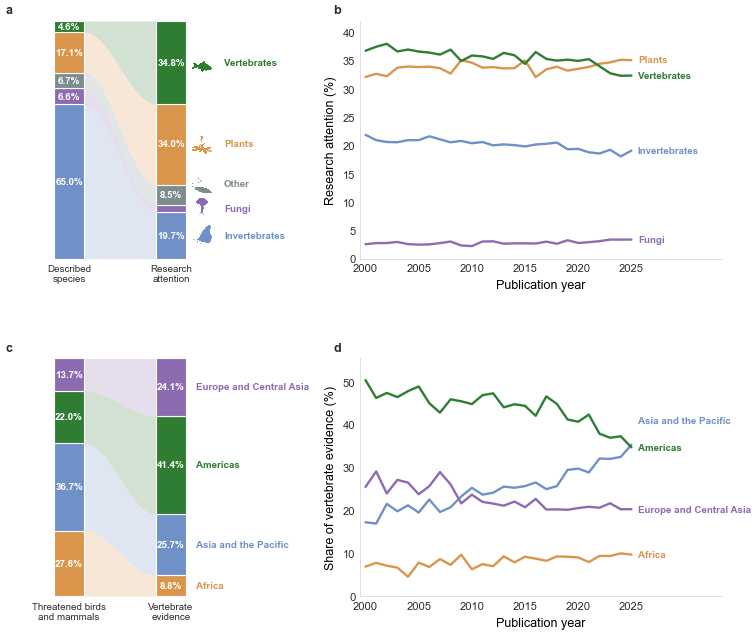

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_anchor_resolution_by_year.csv
Anchor resolution 76.7% (2000) -> 66.9% (2025): later years rest on a smaller share of the corpus, which the Supplementary must state alongside the trend.


In [7]:
STACK_ORDER = tuple(CONFIG["benchmark_group_stack_order"])
RESIDUAL_GROUP = CONFIG["trend_residual_group"]

attention_trend = taxa_skew.taxonomic_attention_trend(
    anchor.included,
    benchmark_groups=BENCHMARK_GROUPS,
)
DESCRIBED_SHARES = ANCHOR["described_species_share_pct"].to_dict()
trend_summary = taxa_skew.summarise_attention_trend(
    attention_trend,
    described_shares=DESCRIBED_SHARES,
)
RESULTS.save_table(attention_trend, artifact("attention_trend_by_year"))
RESULTS.save_table(trend_summary, artifact("attention_trend_summary"))

display(
    trend_summary.set_index("broad_group")
    .reindex(BENCHMARK_GROUPS)
    .reset_index()[
        [
            "broad_group",
            "start_share_pct",
            "end_share_pct",
            "change_pp",
            "slope_pp_per_decade",
            "start_representation_ratio",
            "end_representation_ratio",
        ]
    ]
    .style.format(
        {
            "start_share_pct": "{:.2f}%",
            "end_share_pct": "{:.2f}%",
            "change_pp": "{:+.2f} pp",
            "slope_pp_per_decade": "{:+.2f}",
            "start_representation_ratio": "{:.2f}×",
            "end_representation_ratio": "{:.2f}×",
        }
    )
    .hide(axis="index")
)

# Supplementary robustness: the trend must not be an artefact of the residual bucket
# or of how multi-group publications are split.
SPECIFICATIONS = {
    "Primary (article-balanced)": {},
    f"{RESIDUAL_GROUP} excluded, renormalised": {
        "renormalise_over": [g for g in BENCHMARK_GROUPS if g != RESIDUAL_GROUP]
    },
    "Single-group publications only": {"single_group_only": True},
}
specification_frames = []
for label, keywords in SPECIFICATIONS.items():
    slopes = taxa_skew.summarise_attention_trend(
        taxa_skew.taxonomic_attention_trend(
            anchor.included, benchmark_groups=BENCHMARK_GROUPS, **keywords
        )
    )[["broad_group", "slope_pp_per_decade"]]
    specification_frames.append(slopes.assign(specification=label))

trend_robustness = (
    pd.concat(specification_frames)
    .pivot(index="broad_group", columns="specification", values="slope_pp_per_decade")
    .reindex(index=BENCHMARK_GROUPS, columns=list(SPECIFICATIONS))
    .rename_axis(columns=None)
    .reset_index()
)
RESULTS.save_table(trend_robustness, artifact("attention_trend_robustness"))
print("Slope in points per decade, by specification:")
display(
    trend_robustness.style.format(
        {label: "{:+.2f}" for label in SPECIFICATIONS}
    ).hide(axis="index")
)

# Volume growth is what makes the stability notable, so state it alongside.
YEARLY_TOTALS = (
    attention_trend.groupby("publication_year")["n_effective_publications_year"].first()
    if "n_effective_publications_year" in attention_trend
    else anchor.included.groupby("publication_year").size()
)
first_year, last_year = int(YEARLY_TOTALS.index.min()), int(YEARLY_TOTALS.index.max())
GROWTH_MULTIPLE = YEARLY_TOTALS.loc[last_year] / YEARLY_TOTALS.loc[first_year]
print(
    f"\nAnnual output {YEARLY_TOTALS.loc[first_year]:,.0f} ({first_year}) -> "
    f"{YEARLY_TOTALS.loc[last_year]:,.0f} ({last_year}): {GROWTH_MULTIPLE:.1f}x."
)
TREND = trend_summary.set_index("broad_group")
for group in ("Invertebrates", "Vertebrates"):
    row = TREND.loc[group]
    print(
        f"{group}: {row['start_share_pct']:.1f}% -> {row['end_share_pct']:.1f}% "
        f"({row['slope_pp_per_decade']:+.2f} pp/decade); representation "
        f"{row['start_representation_ratio']:.2f}x -> {row['end_representation_ratio']:.2f}x."
    )

# Combined 2x2: taxonomic mismatch/persistence on top, geographic mismatch/persistence
# below. Both rows call the same _stacked_pair/_trend_lines helpers, so the geographic
# row reads exactly like the taxonomic one -- that rhyme is the argument, since the two
# rows use unrelated benchmarks (GBIF described species, IUCN threatened species) and
# fail alike.
combined_figure = taxa_skew_plotting.plot_representation_and_trend(
    anchor_analysis.comparison,
    attention_trend,
    group_order=STACK_ORDER,
    group_colors=BROAD_COLORS,
    residual_group=RESIDUAL_GROUP,
    mapping=MAPPING,
    regional=gap_regions,
    regional_trend=gap_regional_trend,
    region_order=taxa_gap_plotting.REGION_ORDER,
    region_colors=taxa_gap_plotting.REGION_COLORS,
)
RESULTS.export_figure(
    combined_figure, artifact(CONFIG["combined_figure_filename"])
)
display(combined_figure)
plt.close(combined_figure)

# The caveat the Supplementary must disclose: composition is measured on a shrinking
# share of the corpus, because fewer recent publications resolve to a benchmark group.
ANCHOR_UTS = set(anchor.included["UT"])
resolution_by_year = (
    UNIVERSE.assign(resolved=UNIVERSE["UT"].isin(ANCHOR_UTS))
    .groupby("publication_year")
    .agg(n_universe=("UT", "nunique"), n_resolved=("resolved", "sum"))
    .assign(resolved_pct=lambda d: d["n_resolved"] / d["n_universe"] * 100.0)
    .reset_index()
)
RESULTS.save_table(resolution_by_year, artifact("anchor_resolution_by_year"))
RESOLUTION_START_PCT = float(resolution_by_year["resolved_pct"].iloc[0])
RESOLUTION_END_PCT = float(resolution_by_year["resolved_pct"].iloc[-1])
print(
    f"Anchor resolution {RESOLUTION_START_PCT:.1f}% ({first_year}) -> "
    f"{RESOLUTION_END_PCT:.1f}% ({last_year}): later years rest on a smaller share of "
    "the corpus, which the Supplementary must state alongside the trend."
)

## 3. Interpretation boundaries

What these numbers do and do not license.

In [8]:
BOUNDARIES = [
    "Counts are unique publications; a publication naming several groups is split "
    "across them, never counted once per group.",
    "Attention share measures what is published, not conservation need, ecological "
    "importance, population decline, or undescribed diversity.",
    "The described-diversity benchmark is GBIF accepted species-rank counts — a "
    "described-diversity proxy, not a species inventory. It is weakest for bacteria "
    "and archaea, where described counts trail actual diversity by orders of magnitude.",
    f"{RESOLUTION_START_PCT:.0f}% of in-scope publications resolved to a benchmarkable "
    f"group in {CONFIG['primary_start_year']} and {RESOLUTION_END_PCT:.0f}% in "
    f"{CONFIG['primary_end_year']}; later years rest on a smaller share of the corpus.",
    "The geographic comparison covers "
    f"{GEO_COVERAGE_PCT:.0f}% of the anchor scope -- the share carrying a mapped study "
    "country -- and benchmarks against threatened birds and mammals only, with no "
    "reptile or amphibian indicator, so tropical deficits are floors.",
]
for boundary in BOUNDARIES:
    print(f"• {boundary}")

RESULTS.save_json(
    {
        "analysis": "taxonomic attention versus described diversity, and its trajectory",
        "manuscript_section": CONFIG["manuscript_section"],
        "manuscript_source": MANUSCRIPT_SOURCE,
        "prepared_schema_version": bundle.manifest["schema_version"],
        "prepared_grouping_rules_sha256": bundle.manifest["grouping_rules_sha256"],
        "direction": CONFIG["direction"],
        "primary_years": [CONFIG["primary_start_year"], CONFIG["primary_end_year"]],
        "universe_publications": N_UNIVERSE,
        "anchor_publications": N_ANCHOR,
        "vertebrate_share_pct": round(
            float(ANCHOR.at["Vertebrates", "fractional_attention_share_pct"]), 4
        ),
        "invertebrate_share_pct": round(
            float(ANCHOR.at["Invertebrates", "fractional_attention_share_pct"]), 4
        ),
        "annual_output_growth_multiple": round(float(GROWTH_MULTIPLE), 3),
        "resolution_start_pct": round(float(RESOLUTION_START_PCT), 4),
        "resolution_end_pct": round(float(RESOLUTION_END_PCT), 4),
        "geography_coverage_pct": round(float(GEO_COVERAGE_PCT), 4),
        "bootstrap_replicates": CONFIG["bootstrap_replicates"],
        "random_seed": CONFIG["random_seed"],
        "interpretation_boundaries": BOUNDARIES,
        "reported_tables": [artifact(name) for name in (
            "denominators.csv",
            "attention_vs_described_diversity.csv",
            "attention_trend_by_year.csv",
            "attention_trend_summary.csv",
            "attention_trend_robustness.csv",
            "anchor_resolution_by_year.csv",
            "taxa_geography_coverage.csv",
        )] + [artifact(name) for name in (
            f"{GAP_SLUG}_evidence_vs_threatened_by_region.csv",
            f"{GAP_SLUG}_regional_evidence_trend.csv",
            f"{GAP_SLUG}_regional_evidence_trend_summary.csv",
            f"{GAP_SLUG}_evidence_by_country.csv",
            f"{GAP_SLUG}_regional_evidence_trend_summary_excl_china.csv",
            f"{GAP_SLUG}_evidence_vs_threatened.csv",
            "threatened_species_by_country.csv",
        )],

        "figures": [artifact(f"{CONFIG['combined_figure_filename']}.pdf")],
    },
    artifact("manifest"),
)
print("\nManifest written.")

• Counts are unique publications; a publication naming several groups is split across them, never counted once per group.
• Attention share measures what is published, not conservation need, ecological importance, population decline, or undescribed diversity.
• The described-diversity benchmark is GBIF accepted species-rank counts — a described-diversity proxy, not a species inventory. It is weakest for bacteria and archaea, where described counts trail actual diversity by orders of magnitude.
• 77% of in-scope publications resolved to a benchmarkable group in 2000 and 67% in 2025; later years rest on a smaller share of the corpus.
• The geographic comparison covers 56% of the anchor scope -- the share carrying a mapped study country -- and benchmarks against threatened birds and mammals only, with no reptile or amphibian indicator, so tropical deficits are floors.
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_manifest.json

Mani